In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import recall_score, f1_score, precision_score, confusion_matrix
from sklearn.base import clone 

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Defining Variables
rng_seed = 42

# Custom Metric Weights
w_TP = 1.0   # Reward: Found a defect
w_TN = 0.5   # Reward: Correctly passed good unit
w_FP = -1.0  # Penalty: False Alarm
w_FN = -5.0  # Penalty: Missed Defect 




In [3]:
#Loading Data
raw_data = pd.read_csv('C:\\Users\\0hmse\\PycharmProjects\\Generic Environment\\Statistics\\Final Project\\semiconductor_quality_control.csv')
features = raw_data[['Tool_Type','Chamber_Temperature','Gas_Flow_Rate','RF_Power','Etch_Depth','Rotation_Speed','Vacuum_Pressure','Stage_Alignment_Error','Vibration_Level','UV_Exposure_Intensity','Particle_Count']]
features = pd.get_dummies(features, columns=['Tool_Type'], drop_first=False)
features['Defect'] = raw_data['Defect'] 

# 2. Global Split
train_df, test_df = train_test_split(features, test_size=0.2, stratify=features['Defect'], random_state=rng_seed)
X_test_global = test_df.drop('Defect', axis=1)
y_test_global = test_df['Defect']


In [4]:
# Define Training Function
def train_gbm_ensemble(train_df, X_test, n_estimators=100, learning_rate=0.1, max_depth=3, n_chunks=6, seed=42):
    """
    Trains a GBM ensemble with configurable hyperparameters using chunked undersampling.
    """
    train_majority = train_df[train_df['Defect'] == 0]
    train_minority = train_df[train_df['Defect'] == 1]
    
    # Shuffle and Split Majority
    train_majority = train_majority.sample(frac=1, random_state=seed)
    majority_chunks = np.array_split(train_majority, n_chunks)
    
    # Calculate Sample Weights
    minority_count = len(train_minority)
    majority_count_per_chunk = len(majority_chunks[0])
    minority_weight = majority_count_per_chunk / minority_count
    majority_weight = 1.0
    
    gbm_base_model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        random_state=seed
    )
    
    all_predictions_proba = []
    
    for majority_chunk in majority_chunks:
        current_train_df = pd.concat([majority_chunk, train_minority], ignore_index=True).sample(frac=1, random_state=seed)
        X_train_chunk = current_train_df.drop('Defect', axis=1)
        y_train_chunk = current_train_df['Defect']
        
        sample_weights = np.where(y_train_chunk == 1, minority_weight, majority_weight)
        
        gbm_model = clone(gbm_base_model)
        gbm_model.fit(X_train_chunk, y_train_chunk, sample_weight=sample_weights)
        probs = gbm_model.predict_proba(X_test)[:, 1]
        all_predictions_proba.append(probs)
        
    return np.mean(all_predictions_proba, axis=0)



In [5]:
# THIS WILL TAKE THE LONGEST, GO GET A SANDWICH OR SOMETHING

# Grid Search Hyper Parameters
#n_estimators_list = [50, 100, 200]
#learning_rate_list = [0.05, 0.1, 0.2]
#max_depth_list = [3, 4, 5]
#threshold_list = np.arange(0.1, 0.95, 0.05)

# Grid Search Hyper Parameters
# 7.5 minute to run on 3.5 ghz desktop processor
n_estimators_list = [50, 100, 200, 500]
learning_rate_list = [0.05, 0.1, 0.2, .5, 1]
max_depth_list = [3, 4, 5, 6]
threshold_list = np.arange(0.1, 0.95, 0.05)

#🏆 BEST RECALL: 1.0000
#   Params: {'n_estimators': 50, 'learning_rate': 0.5, 'max_depth': 6, 'threshold': np.float64(0.15000000000000002)}

#🏆 BEST PRECISION: 0.5000
#   Params: {'n_estimators': 50, 'learning_rate': 0.5, 'max_depth': 4, 'threshold': np.float64(0.9000000000000002)}

#🏆 BEST F1-SCORE: 0.2623
#   Params: {'n_estimators': 50, 'learning_rate': 0.5, 'max_depth': 6, 'threshold': np.float64(0.15000000000000002)}

#★ BEST CUSTOM METRIC SCORE: -238.00
#   Params: {'n_estimators': 50, 'learning_rate': 0.5, 'max_depth': 5, 'threshold': np.float64(0.8000000000000002)}



# Initialize Best Trackers
best_recall = -1
best_recall_params = {}

best_precision = -1
best_precision_params = {}

best_f1 = -1
best_f1_params = {}

# New Tracker for Custom Metric
best_custom_score = -float('inf') # Start with negative infinity
best_custom_params = {}

config_count = 0

print(f"Starting Optimization Loop...")

for n_est in n_estimators_list:
    for lr in learning_rate_list:
        for depth in max_depth_list:
            config_count += 1
            print(f"Training Config {config_count}: n_estimators={n_est}, lr={lr}, depth={depth}")
            
            # Train ONCE
            avg_probs = train_gbm_ensemble(
                train_df, X_test_global, 
                n_estimators=n_est, learning_rate=lr, max_depth=depth, n_chunks=6
            )
            
            # Loop Thresholds
            for thresh in threshold_list:
                y_pred = (avg_probs >= thresh).astype(int)
                
                # Standard Metrics
                curr_recall = recall_score(y_test_global, y_pred)
                curr_precision = precision_score(y_test_global, y_pred, zero_division=0)
                curr_f1 = f1_score(y_test_global, y_pred)
                
                # --- CUSTOM METRIC CALCULATION ---
                tn, fp, fn, tp = confusion_matrix(y_test_global, y_pred).ravel()
                
                # Calculate weighted score
                curr_custom_score = (w_TP * tp) + (w_TN * tn) + (w_FP * fp) + (w_FN * fn)
                
                # Store Params
                curr_params = {
                    'n_estimators': n_est,
                    'learning_rate': lr,
                    'max_depth': depth,
                    'threshold': thresh
                }
                
                # Update Bests
                if curr_recall > best_recall:
                    best_recall = curr_recall
                    best_recall_params = curr_params
                elif curr_recall == best_recall and curr_f1 > best_f1: # Tie-breaker
                     best_recall_params = curr_params
                     
                if curr_precision > best_precision:
                    best_precision = curr_precision
                    best_precision_params = curr_params
                    
                if curr_f1 > best_f1:
                    best_f1 = curr_f1
                    best_f1_params = curr_params
                    
                # Update Best Custom Score
                if curr_custom_score > best_custom_score:
                    best_custom_score = curr_custom_score
                    best_custom_params = curr_params

# --- 5. REPORT RESULTS ---

print("\n" + "="*50)
print("      OPTIMIZATION RESULTS      ")
print("="*50)

print(f"\n🏆 BEST RECALL: {best_recall:.4f}")
print(f"   Params: {best_recall_params}")

print(f"\n🏆 BEST PRECISION: {best_precision:.4f}")
print(f"   Params: {best_precision_params}")

print(f"\n🏆 BEST F1-SCORE: {best_f1:.4f}")
print(f"   Params: {best_f1_params}")

print(f"\n★ BEST CUSTOM METRIC SCORE: {best_custom_score:.2f}")
print(f"   Params: {best_custom_params}")

Starting Optimization Loop...
Training Config 1: n_estimators=50, lr=0.05, depth=3
Training Config 2: n_estimators=50, lr=0.05, depth=4
Training Config 3: n_estimators=50, lr=0.05, depth=5
Training Config 4: n_estimators=50, lr=0.05, depth=6
Training Config 5: n_estimators=50, lr=0.1, depth=3
Training Config 6: n_estimators=50, lr=0.1, depth=4
Training Config 7: n_estimators=50, lr=0.1, depth=5
Training Config 8: n_estimators=50, lr=0.1, depth=6
Training Config 9: n_estimators=50, lr=0.2, depth=3
Training Config 10: n_estimators=50, lr=0.2, depth=4
Training Config 11: n_estimators=50, lr=0.2, depth=5
Training Config 12: n_estimators=50, lr=0.2, depth=6
Training Config 13: n_estimators=50, lr=0.5, depth=3
Training Config 14: n_estimators=50, lr=0.5, depth=4
Training Config 15: n_estimators=50, lr=0.5, depth=5
Training Config 16: n_estimators=50, lr=0.5, depth=6
Training Config 17: n_estimators=50, lr=1, depth=3
Training Config 18: n_estimators=50, lr=1, depth=4
Training Config 19: n_est

In [6]:
def graph_metric_vs_estimators(train_df, X_test, y_test, estimator_list, lr_list, metric_name='custom', fixed_depth=3, fixed_threshold=0.5):
    """
    Graphs a specific Metric vs. # of Estimators for different Learning Rates.
    Also displays the Confusion Matrix for the OPTIMAL configuration found.
    
    Parameters:
    - metric_name: 'custom', 'f1', 'recall', or 'precision'
    """
    
    plt.figure(figsize=(12, 7))
    
    # Trackers for the "Best" Model found during the loops
    best_score = -float('inf')
    best_cm = None
    best_params = {}
    
    # Loop over each learning rate
    for lr in lr_list:
        scores = []
        print(f"Collecting data for Learning Rate: {lr}...")
        
        for n_est in estimator_list:
            # 1. Train Model
            # (Assumes train_gbm_ensemble is defined as in your previous code)
            avg_probs = train_gbm_ensemble(
                train_df, X_test, 
                n_estimators=n_est, 
                learning_rate=lr, 
                max_depth=fixed_depth, 
                n_chunks=6
            )
            
            # 2. Apply Threshold
            y_pred = (avg_probs >= fixed_threshold).astype(int)
            
            # 3. Calculate the selected Metric
            current_score = 0.0
            
            if metric_name == 'custom':
                tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
                # Ensure global weights (w_TP, etc.) are defined or passed
                current_score = (w_TP * tp) + (w_TN * tn) + (w_FP * fp) + (w_FN * fn)
            elif metric_name == 'f1':
                current_score = f1_score(y_test, y_pred)
            elif metric_name == 'recall':
                current_score = recall_score(y_test, y_pred)
            elif metric_name == 'precision':
                current_score = precision_score(y_test, y_pred, zero_division=0)
            else:
                raise ValueError("metric_name must be 'custom', 'f1', 'recall', or 'precision'")
            
            scores.append(current_score)
            
            # 4. Check if this is the new Best Model
            if current_score > best_score:
                best_score = current_score
                best_cm = confusion_matrix(y_test, y_pred)
                best_params = {'n_estimators': n_est, 'lr': lr}

        # Plot the line for this learning rate
        plt.plot(estimator_list, scores, marker='o', linewidth=2, label=f'LR = {lr}')

    # --- PART A: Plotting the Line Graph ---
    plt.title(f'{metric_name.capitalize()} Score vs. # of Estimators\n(Depth={fixed_depth}, Threshold={fixed_threshold})', fontsize=14)
    plt.xlabel('Number of Estimators', fontsize=12)
    plt.ylabel(f'{metric_name.capitalize()} Score', fontsize=12)
    plt.legend(title="Learning Rate")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    # --- PART B: Plotting the Best Confusion Matrix ---
    print(f"\n🏆 Optimal {metric_name.capitalize()} Score Found: {best_score:.4f}")
    print(f"   Configuration: {best_params}")
    
    if best_cm is not None:
        plt.figure(figsize=(6, 6))
        plt.matshow(best_cm, cmap='Blues', fignum=1)
        plt.title(f'Confusion Matrix for Best {metric_name.capitalize()} Model', y=1.2)
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        
        # Add labels
        class_labels = ['0', '1']
        plt.xticks([0, 1], class_labels)
        plt.yticks([0, 1], class_labels)

        # Annotate cells
        for i in range(best_cm.shape[0]):
            for j in range(best_cm.shape[1]):
                plt.text(j, i, format(best_cm[i, j], 'd'),
                         ha="center", va="center", 
                         color="white" if best_cm[i, j] > best_cm.max() / 2 else "black",
                         fontsize=16)
        plt.show()


--- Generating Graph ---


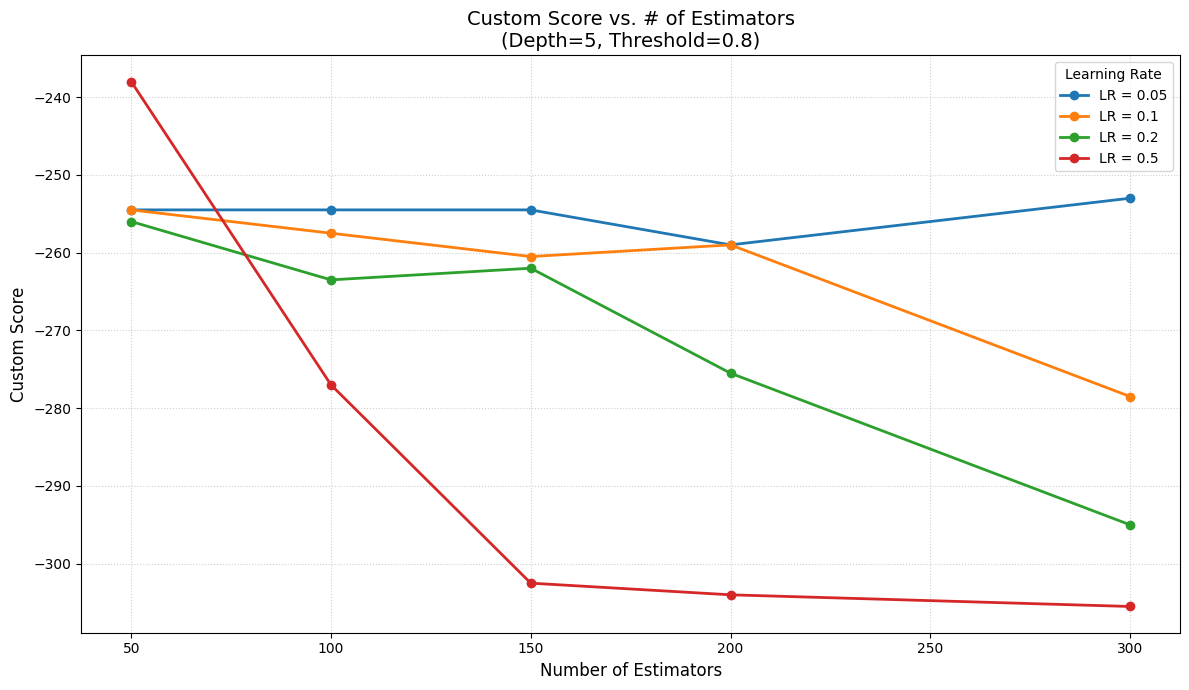


🏆 Optimal Custom Score Found: -238.0000
   Configuration: {'n_estimators': 50, 'lr': 0.5}


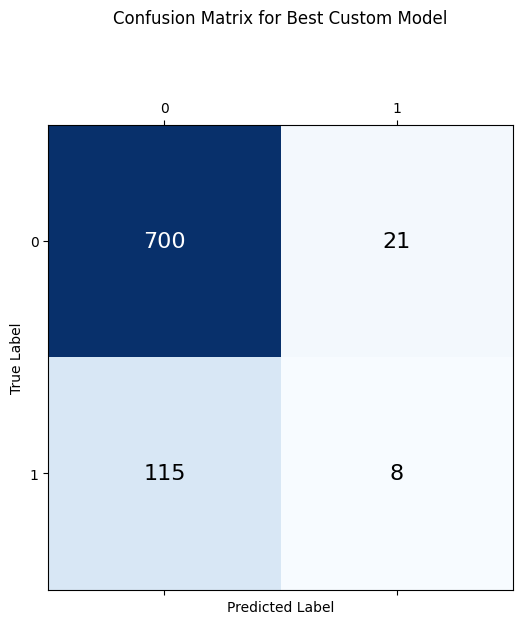

In [7]:
# Best Custom Parameter ballpark

# WARNING NEEDS TO RETRAIN MODELS BUT MUCH FEWER THAN OPTIMIZATION

# 1. Define lists for the graph
estimators_to_test = [50, 100, 150, 200, 300]
learning_rates_to_test = [0.05, 0.1, 0.2, .5]

# 2. Run the Graphing Function
print("\n--- Generating Graph ---")
graph_metric_vs_estimators(
    train_df, X_test_global, y_test_global, 
    estimator_list=estimators_to_test, 
    lr_list=learning_rates_to_test, 
    metric_name='custom',       # <--- Graphs custom metric
    fixed_depth=5, 
    fixed_threshold=0.8
)


--- Generating Graph ---


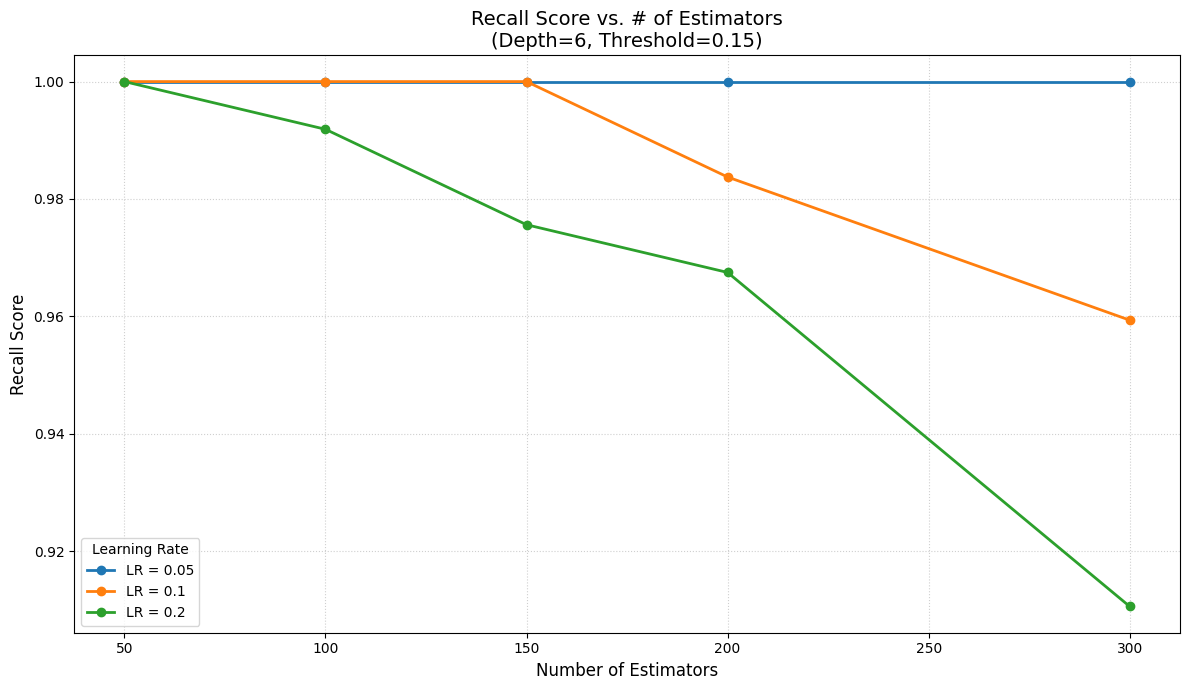


🏆 Optimal Recall Score Found: 1.0000
   Configuration: {'n_estimators': 50, 'lr': 0.05}


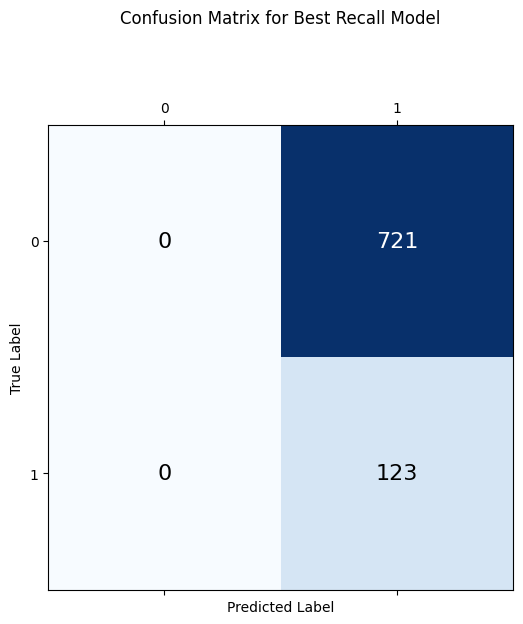

In [8]:
# Best Recall ballpark

# WARNING NEEDS TO RETRAIN MODELS BUT MUCH FEWER THAN OPTIMIZATION

# 1. Define lists for the graph
estimators_to_test = [50, 100, 150, 200, 300]
learning_rates_to_test = [0.05, 0.1, 0.2]

# 2. Run the Graphing Function
# We use a fixed threshold (e.g., 0.5) to isolate the effect of estimators/LR.
# If you found a better threshold in the previous step (e.g. 0.3), change it here!
print("\n--- Generating Graph ---")
graph_metric_vs_estimators(
    train_df, X_test_global, y_test_global, 
    estimator_list=estimators_to_test, 
    lr_list=learning_rates_to_test, 
    metric_name='recall',       # <--- Graphs custom metric
    fixed_depth=6, 
    fixed_threshold=0.15
)


--- Generating Graph ---


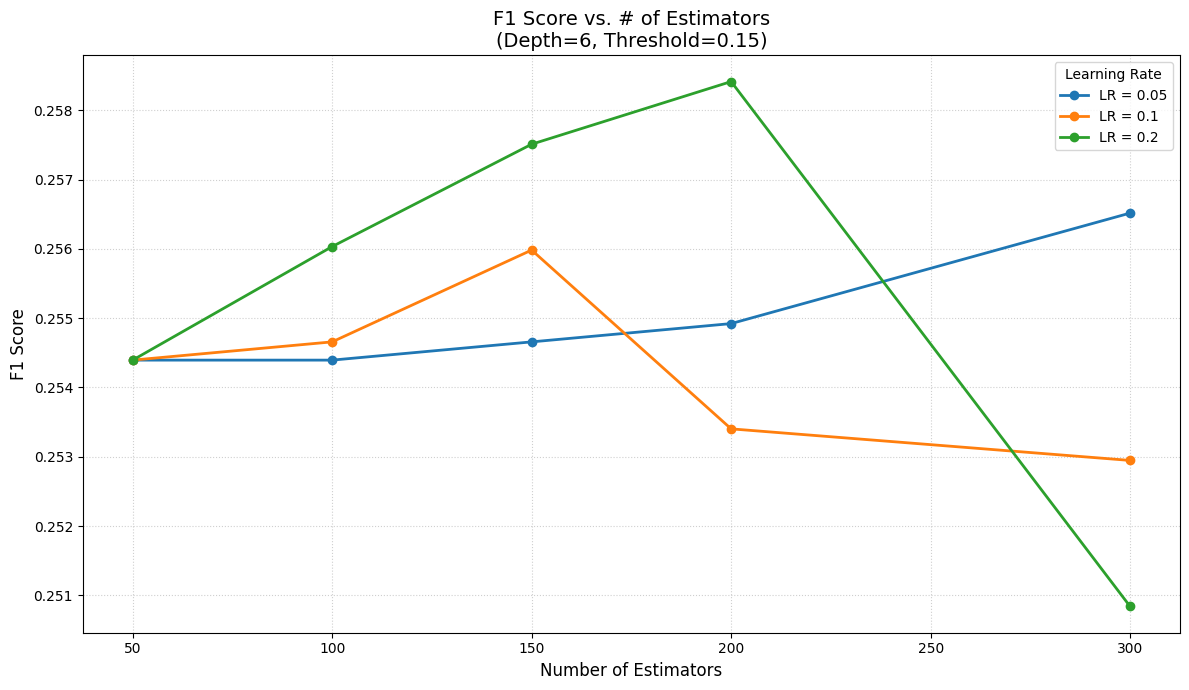


🏆 Optimal F1 Score Found: 0.2584
   Configuration: {'n_estimators': 200, 'lr': 0.2}


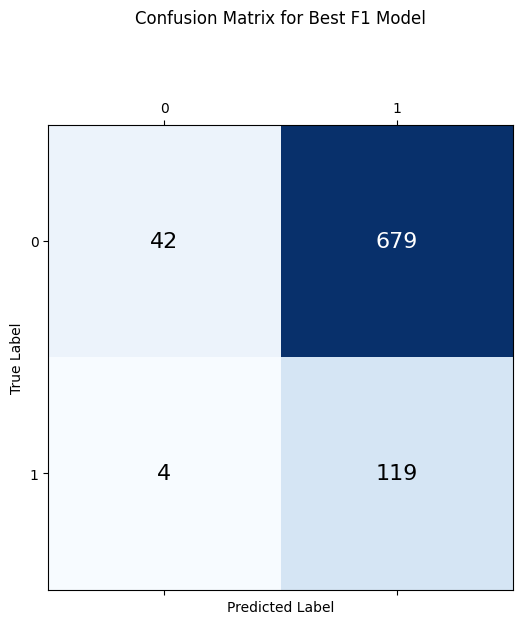

In [9]:
# Best F-1 Ballpark

# WARNING NEEDS TO RETRAIN MODELS BUT MUCH FEWER THAN OPTIMIZATION

# 1. Define lists for the graph
estimators_to_test = [50, 100, 150, 200, 300]
learning_rates_to_test = [0.05, 0.1, 0.2]

# 2. Run the Graphing Function
# We use a fixed threshold (e.g., 0.5) to isolate the effect of estimators/LR.
# If you found a better threshold in the previous step (e.g. 0.3), change it here!
print("\n--- Generating Graph ---")
graph_metric_vs_estimators(
    train_df, X_test_global, y_test_global, 
    estimator_list=estimators_to_test, 
    lr_list=learning_rates_to_test, 
    metric_name='f1',       # <--- Graphs custom metric
    fixed_depth=6, 
    fixed_threshold=0.15
)